Create a circuit with 7 qubits, say  q[6],…,q[0]  in the reading order of Qiskit.

Set the states of the top six qubits to  |0⟩ .

Set the state of the bottom qubit to  |1⟩ .

Apply Hadamard operators to all qubits.

Apply CNOT operator ( q[1] , q[0] )
Apply CNOT operator ( q[4] , q[0] )
Apply CNOT operator ( q[5] , q[0] )

Apply Hadamard operators to all qubits.

Measure all qubits.

For each CNOT operator, is there a phase-kickback effect?

In [ ]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc

Initial state: dict_keys([np.str_('0000001')])


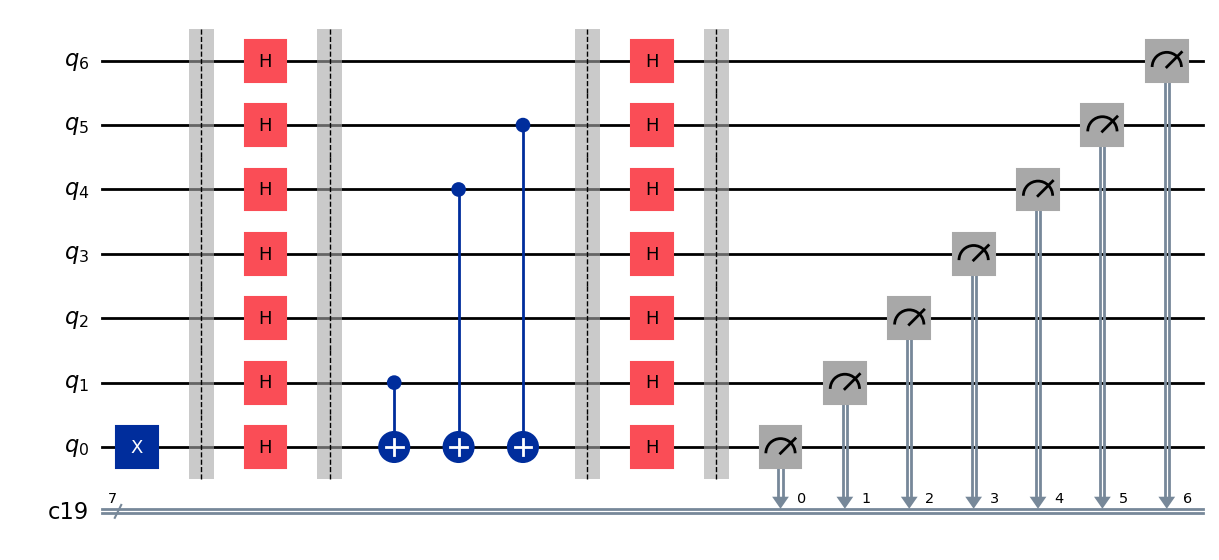

Simulation {'0110011': 100}


In [23]:
# import all necessary objects and methods for quantum circuits
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit #for qiskit version 2.x
from qiskit_aer import Aer #for qiskit version 2.x
from qiskit.quantum_info import Statevector

# Create a circuit with 7 qubits.
q =  QuantumRegister(7,"q") # quantum register with 7 qubits
c = ClassicalRegister(7) # classical register with 7 bits

qc = QuantumCircuit(q,c) # quantum circuit with quantum and classical registers

# the top six qubits are already in |0>

# set the bottom qubit to |1>
qc.x(0) # apply x-gate (NOT operator)

#print the initial state
initial_state = Statevector(qc)
print("Initial state:", initial_state.to_dict().keys())

# define a barrier
qc.barrier()

# apply Hadamard to all qubits.
for i in range(7):
    qc.h(q[i])

    # define a barrier
qc.barrier()


# apply CNOT operator (q[1],q[0])
# apply CNOT operator (q[4],q[0])
# apply CNOT operator (q[5],q[0])
qc.cx(q[1],q[0])
qc.cx(q[4],q[0])
qc.cx(q[5],q[0])

# define a barrier
qc.barrier()


# apply Hadamard to all qubits.
for i in range(7):
    qc.h(q[i])

# define a barrier
qc.barrier()

# measure all qubits
qc.measure(q,c)


# draw the circuit in Qiskit reading order
display(qc.draw(output='mpl',reverse_bits=True))

# execute the circuit 100 times in the local simulator
# job = execute(qc,Aer.get_backend('qasm_simulator'),shots=100) # for qiskit version 1.x
simulator = Aer.get_backend('qasm_simulator') # for qiskit version 2.x
job = simulator.run(qc,shots=100)
counts = job.result().get_counts(qc)
print("Simulation", counts)